# Data Exploration


In [2]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import Audio, display

def display_audio_spectrogram(filepath: str, title: str = None):
    """
    Load an audio file, display its mel spectrogram, and provide a playback widget.
    
    Args:
        filepath: Path to the audio file (.ogg, .wav, .mp3, etc.)
        title:    Optional title override. Defaults to the filename.
    """
    SAMPLE_RATE = 32_000
    N_FFT       = 1024
    HOP_LENGTH  = 320
    N_MELS      = 128
    F_MIN       = 50
    F_MAX       = 16_000

    # --- Load ---
    waveform, sr = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
    duration     = len(waveform) / sr

    # --- Mel spectrogram ---
    mel      = librosa.feature.melspectrogram(
        y=waveform, sr=sr,
        n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=F_MIN, fmax=F_MAX,
    )
    mel_db   = librosa.power_to_db(mel, ref=np.max)

    # --- Waveform (for amplitude plot) ---
    times = np.linspace(0, duration, num=len(waveform))

    # --- Plot ---
    fig = plt.figure(figsize=(14, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.35)

    # Top: waveform
    ax_wave = fig.add_subplot(gs[0])
    ax_wave.plot(times, waveform, color="#4C9BE8", linewidth=0.5, alpha=0.85)
    ax_wave.set_xlim(0, duration)
    ax_wave.set_ylabel("Amplitude")
    ax_wave.set_xlabel("Time (s)")
    ax_wave.set_title("Waveform")
    ax_wave.axhline(0, color="white", linewidth=0.4, alpha=0.4)
    ax_wave.grid(True, alpha=0.2)

    # Bottom: mel spectrogram
    ax_spec = fig.add_subplot(gs[1])
    img = librosa.display.specshow(
        mel_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        fmin=F_MIN,
        fmax=F_MAX,
        x_axis="time",
        y_axis="mel",
        ax=ax_spec,
        cmap="magma",
    )
    fig.colorbar(img, ax=ax_spec, format="%+2.0f dB", pad=0.01)
    ax_spec.set_title("Mel Spectrogram")
    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_ylabel("Frequency (Hz)")

    fig_title = title or filepath.split("/")[-1]
    fig.suptitle(fig_title, fontsize=13, fontweight="bold", y=1.01)

    plt.show()

    # --- Audio player ---
    print(f"Duration: {duration:.2f}s  |  Sample rate: {sr} Hz  |  Samples: {len(waveform):,}")
    display(Audio(data=waveform, rate=sr))

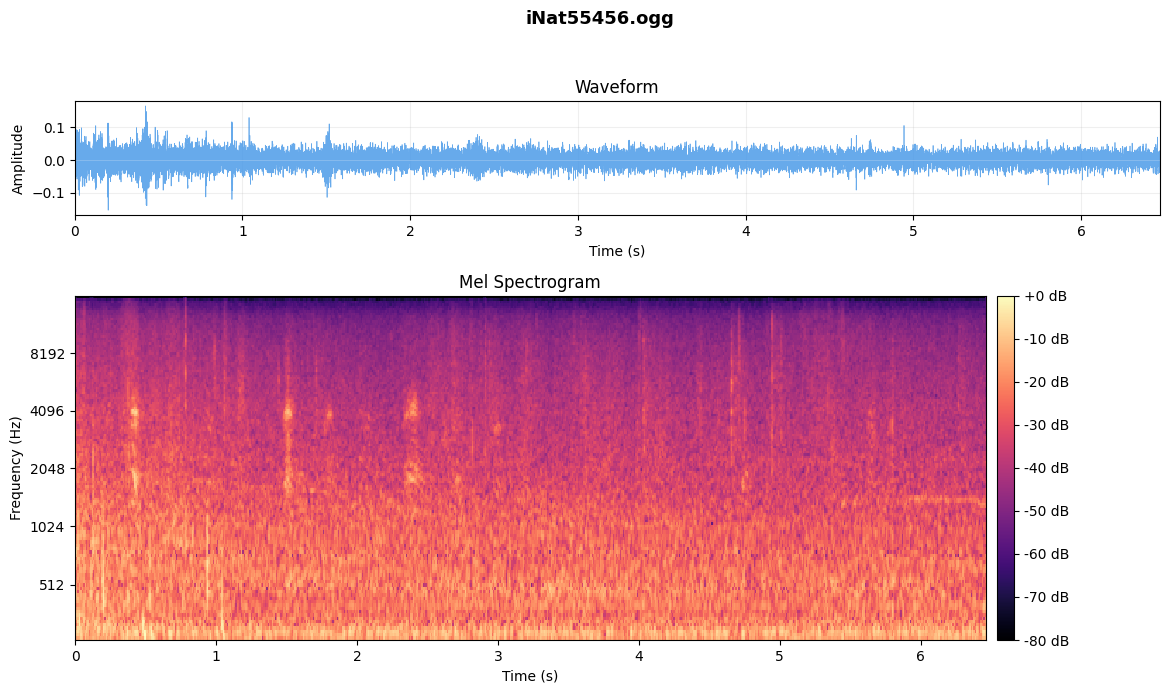

Duration: 6.47s  |  Sample rate: 32000 Hz  |  Samples: 207,000


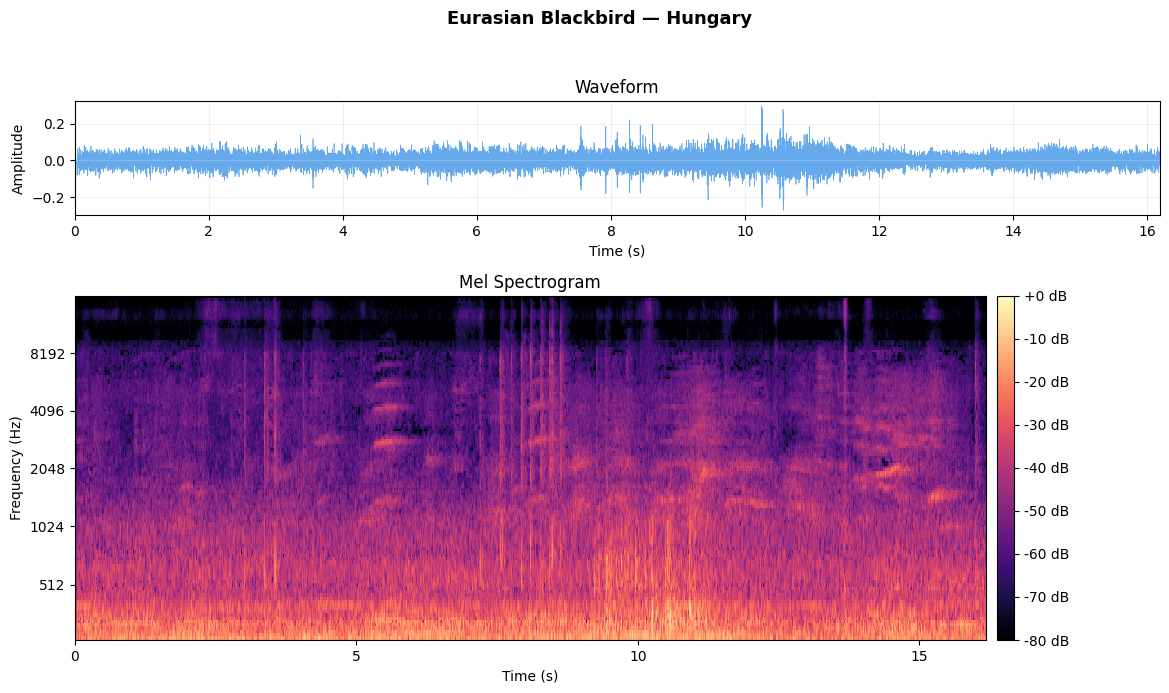

Duration: 16.18s  |  Sample rate: 32000 Hz  |  Samples: 517,877


In [3]:
display_audio_spectrogram("../dataset/birdclef-2025/train_audio/42113/iNat55456.ogg")

# With a custom title
display_audio_spectrogram("../dataset/birdclef-2025/train_audio/42113/iNat557906.ogg", title="Eurasian Blackbird — Hungary")

In [4]:
import pandas as pd

df = pd.read_csv("../dataset/birdclef-2025/train.csv")

# Estimated chunks per species (assuming ~average duration)
# You'll need to join with actual file durations
chunks_per_species = df.groupby("primary_label").size()

print(chunks_per_species.describe())
print(f"\nSpecies with < 5 files: {(chunks_per_species < 5).sum()}")
print(f"Species with > 50 files: {(chunks_per_species > 50).sum()}")

count    206.000000
mean     138.660194
std      169.177583
min        2.000000
25%       19.000000
50%       80.500000
75%      182.750000
max      990.000000
dtype: float64

Species with < 5 files: 23
Species with > 50 files: 126


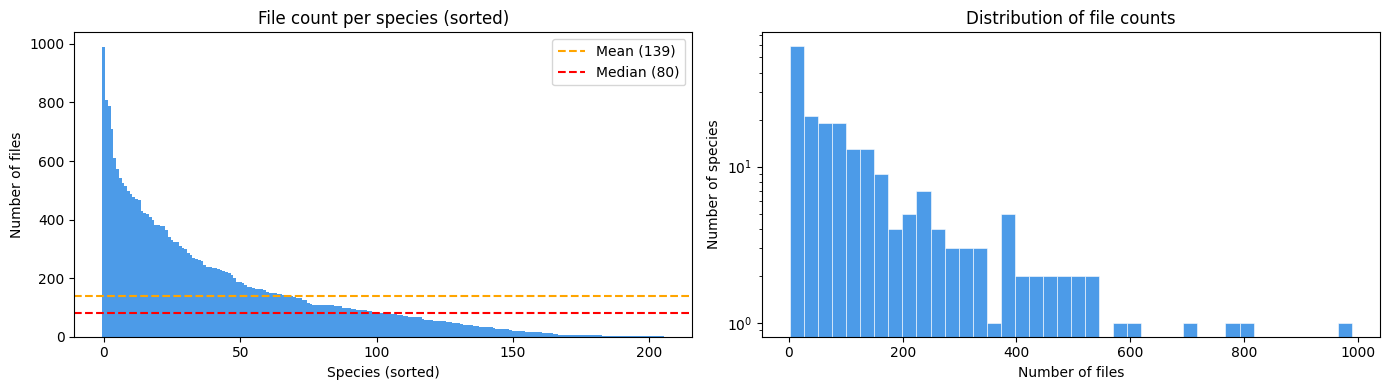

In [5]:
import matplotlib.pyplot as plt
import numpy as np

counts = chunks_per_species.sort_values(ascending=False).values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: sorted bar (shows the long tail clearly)
axes[0].bar(range(len(counts)), counts, color="#4C9BE8", width=1.0)
axes[0].axhline(counts.mean(), color="orange", linestyle="--", label=f"Mean ({counts.mean():.0f})")
axes[0].axhline(np.median(counts), color="red",    linestyle="--", label=f"Median ({np.median(counts):.0f})")
axes[0].set_xlabel("Species (sorted)")
axes[0].set_ylabel("Number of files")
axes[0].set_title("File count per species (sorted)")
axes[0].legend()

# Right: log-scale histogram (shows the shape of the distribution)
axes[1].hist(counts, bins=40, color="#4C9BE8", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Number of files")
axes[1].set_ylabel("Number of species")
axes[1].set_title("Distribution of file counts")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import os

df = pd.read_csv("../dataset/birdclef-2025/train.csv")

# Adjust this path to where your audio files are
AUDIO_DIR = "../dataset/birdclef-2025/train_audio"
SAMPLE_RATE = 32_000
CHUNK_DURATION = 5  # seconds
CHUNK_SAMPLES = SAMPLE_RATE * CHUNK_DURATION

def estimate_chunks(filepath):
    try:
        info = sf.info(filepath)
        total_samples = int(info.duration * SAMPLE_RATE)
        return max(1, total_samples // CHUNK_SAMPLES)
    except:
        return 0

import soundfile as sf

df["filepath"] = AUDIO_DIR + "/" + df["filename"]
df["chunk_count"] = df["filepath"].apply(estimate_chunks)

chunks_per_species = df.groupby("primary_label")["chunk_count"].sum()

print(chunks_per_species.describe())
print(f"\nSpecies with < 10 chunks: {(chunks_per_species < 10).sum()}")
print(f"Species with > 500 chunks: {(chunks_per_species > 500).sum()}")

count     206.000000
mean      923.072816
std      1177.742884
min         2.000000
25%       134.000000
50%       498.500000
75%      1233.000000
max      6130.000000
Name: chunk_count, dtype: float64

Species with < 10 chunks: 11
Species with > 500 chunks: 102


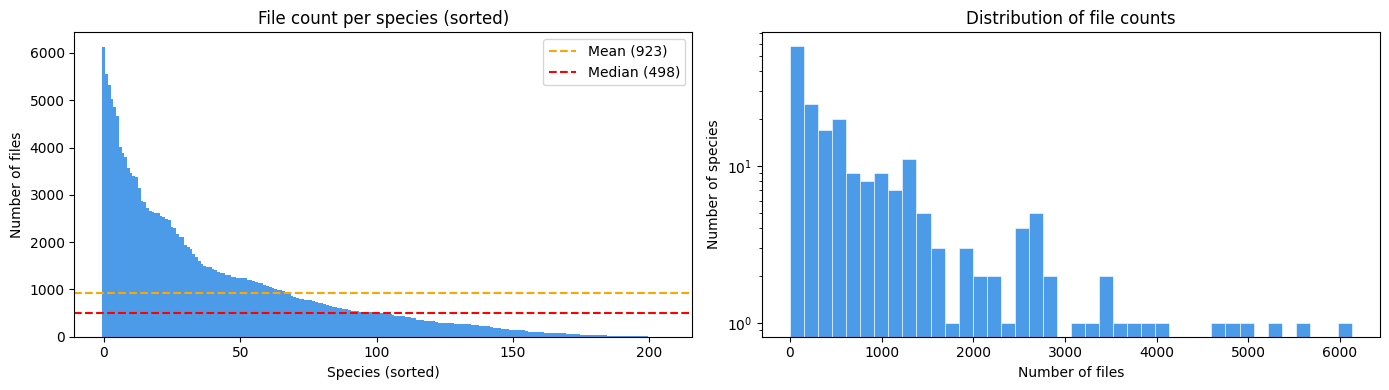

In [7]:
import matplotlib.pyplot as plt
import numpy as np

counts = chunks_per_species.sort_values(ascending=False).values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: sorted bar (shows the long tail clearly)
axes[0].bar(range(len(counts)), counts, color="#4C9BE8", width=1.0)
axes[0].axhline(counts.mean(), color="orange", linestyle="--", label=f"Mean ({counts.mean():.0f})")
axes[0].axhline(np.median(counts), color="red",    linestyle="--", label=f"Median ({np.median(counts):.0f})")
axes[0].set_xlabel("Species (sorted)")
axes[0].set_ylabel("Number of files")
axes[0].set_title("File count per species (sorted)")
axes[0].legend()

# Right: log-scale histogram (shows the shape of the distribution)
axes[1].hist(counts, bins=40, color="#4C9BE8", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Number of files")
axes[1].set_ylabel("Number of species")
axes[1].set_title("Distribution of file counts")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

# Preprocessing

### Imports

In [8]:
import os
import pandas as pd
import soundfile as sf
from sklearn.model_selection import train_test_split

### Config

In [9]:
AUDIO_DIR      = "../dataset/birdclef-2025/train_audio"
CSV_PATH       = "../dataset/birdclef-2025/train.csv"
OUTPUT_DIR     = "../dataset"

SAMPLE_RATE    = 32_000
CHUNK_DURATION = 5
CHUNK_SAMPLES  = SAMPLE_RATE * CHUNK_DURATION

### Build chunk manifest

In [10]:
df = pd.read_csv(CSV_PATH)

rows = []
skipped_files = 0

for _, file_row in df.iterrows():
    filepath = os.path.join(AUDIO_DIR, file_row["filename"])

    try:
        info          = sf.info(filepath)
        total_samples = int(info.duration * SAMPLE_RATE)
    except Exception as e:
        print(f"Skipping {file_row['filename']}: {e}")
        skipped_files += 1
        continue

    if total_samples < CHUNK_SAMPLES:
        skipped_files += 1
        continue

    start = 0
    while start + CHUNK_SAMPLES <= total_samples:
        rows.append({
            "filename":      file_row["filename"],
            "primary_label": file_row["primary_label"],
            "start_sample":  start,
        })
        start += CHUNK_SAMPLES

manifest = pd.DataFrame(rows)

print(f"Total chunks:      {len(manifest)}")
print(f"Skipped files:     {skipped_files}")
print(f"Species:           {manifest['primary_label'].nunique()}")

Total chunks:      187839
Skipped files:     2314
Species:           205


### Sanity check
Verify chunk counts per species match earlier exploration

In [11]:
# Cell 4 — Verify chunk counts per species match earlier exploration
chunks_per_species = manifest.groupby("primary_label")["filename"].count()
print(chunks_per_species.describe())
print(f"\nSpecies with < 10 chunks: {(chunks_per_species < 10).sum()}")
print(f"Species with > 500 chunks: {(chunks_per_species > 500).sum()}")

count     205.000000
mean      916.287805
std      1169.029713
min         1.000000
25%       140.000000
50%       496.000000
75%      1208.000000
max      6099.000000
Name: filename, dtype: float64

Species with < 10 chunks: 10
Species with > 500 chunks: 100


### Train / Val / Test split

In [12]:
# Cell 5 — Train / val / test split

MIN_CHUNKS_FIRST  = 3   # for the first split (train vs temp)
MIN_CHUNKS_SECOND = 2   # for the second split (val vs test)

chunk_counts = manifest.groupby("primary_label")["filename"].transform("count")

too_few_first = manifest[chunk_counts < MIN_CHUNKS_FIRST]
splittable    = manifest[chunk_counts >= MIN_CHUNKS_FIRST]

print(f"Forced into train (< {MIN_CHUNKS_FIRST} chunks): {too_few_first['primary_label'].nunique()} species, {len(too_few_first)} chunks")

train_df, temp_df = train_test_split(
    splittable,
    test_size=0.2,
    random_state=42,
    stratify=splittable["primary_label"]
)

# Some species may have only 1 chunk in temp_df after the first split
temp_counts       = temp_df.groupby("primary_label")["filename"].transform("count")
too_few_second    = temp_df[temp_counts < MIN_CHUNKS_SECOND]
temp_splittable   = temp_df[temp_counts >= MIN_CHUNKS_SECOND]

print(f"Forced into val   (< {MIN_CHUNKS_SECOND} chunks in temp): {too_few_second['primary_label'].nunique()} species, {len(too_few_second)} chunks")

val_df, test_df = train_test_split(
    temp_splittable,
    test_size=0.5,
    random_state=42,
    stratify=temp_splittable["primary_label"]
)

# Merge leftovers
train_df = pd.concat([train_df, too_few_first],  ignore_index=True)
val_df   = pd.concat([val_df,   too_few_second], ignore_index=True)

print(f"\nTrain: {len(train_df):>7} chunks  ({len(train_df)/len(manifest)*100:.1f}%)")
print(f"Val:   {len(val_df):>7} chunks  ({len(val_df)/len(manifest)*100:.1f}%)")
print(f"Test:  {len(test_df):>7} chunks  ({len(test_df)/len(manifest)*100:.1f}%)")
print(f"\nSpecies in train: {train_df['primary_label'].nunique()}")
print(f"Species in val:   {val_df['primary_label'].nunique()}")
print(f"Species in test:  {test_df['primary_label'].nunique()}")

Forced into train (< 3 chunks): 1 species, 1 chunks
Forced into val   (< 2 chunks in temp): 6 species, 6 chunks

Train:  150271 chunks  (80.0%)
Val:     18787 chunks  (10.0%)
Test:    18781 chunks  (10.0%)

Species in train: 205
Species in val:   201
Species in test:  195


### Save manifests

In [13]:
train_df.to_csv(os.path.join(OUTPUT_DIR, "train_manifest.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "val_manifest.csv"),     index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test_manifest.csv"),   index=False)

print("Saved:")
print(f"  {OUTPUT_DIR}/train_manifest.csv")
print(f"  {OUTPUT_DIR}/val_manifest.csv")
print(f"  {OUTPUT_DIR}/test_manifest.csv")

Saved:
  ../dataset/train_manifest.csv
  ../dataset/val_manifest.csv
  ../dataset/test_manifest.csv
